# **Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and Matplotlib/Seaborn**

### **Objective:**

This project highlights EDA using Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. It focuses on analyzing data from  Excel Spreadsheets and integrated multiple tables (e.g., Sales, Invoice, Product). Performed cleaning, transformation, and visualisation using Python (Pandas, Matplotlib, Seaborn) to identify trends, distributions, and correlations

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### 1️⃣ Load the Excel File
<strong> Objective: Import the data from the provided Excel file into Python using Pandas.</strong>

In [3]:
import pandas as pd

# Define full_path to the Excel file store in the notebook built-in resources

full_path = f"{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx"

# Read each sheet from the Excel file into separate Dataframes 
df_sales = pd.read_excel(full_path, sheet_name="Sales")
df_invoice = pd.read_excel(full_path, sheet_name="Invoice")
df_product = pd.read_excel(full_path, sheet_name="Product")

# Display information and first few rows of each dataframe
print("Sales DataFrame:")
display(df_sales.info())
display(df_sales.head())

print("Invoice DataFrame:")
display(df_invoice.info())
display(df_invoice.head())

print("Product DataFrame:")
display(df_product.info())
display(df_product.head())



Sales DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83277 entries, 0 to 83276
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    83277 non-null  int64         
 1   StockCode    83277 non-null  int64         
 2   Quantity     83277 non-null  int64         
 3   UnitPrice    83277 non-null  float64       
 4   InvoiceDate  83277 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 3.2 MB


Invoice DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27759 entries, 0 to 27758
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   InvoiceNo  27759 non-null  int64 
 1   Country    27759 non-null  object
dtypes: int64(1), object(1)
memory usage: 433.9+ KB


Product DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   StockCode         2834 non-null   int64 
 1   Description       2834 non-null   object
 2   Product_Category  2834 non-null   object
dtypes: int64(1), object(2)
memory usage: 66.6+ KB


In [2]:
print(df_sales.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83277 entries, 0 to 83276
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    83277 non-null  int64         
 1   StockCode    83277 non-null  int64         
 2   Quantity     83277 non-null  int64         
 3   UnitPrice    83277 non-null  float64       
 4   InvoiceDate  83277 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 3.2 MB
None


### 2️⃣ Basic Python and Pandas Operations
Objective: Perform basic Python and Pandas operations to manipulate the data.

<strong>2️⃣.1️⃣ Check for missing values in the Sales DataFrame.</strong>

In [4]:
# Check for missing values by using isnull()
missing_count = df_sales.isnull().sum()

# Display only rows with null values
rows_with_nulls = df_sales[df_sales.isnull().any(axis=1)]
print("Missing values in each column:")
display(missing_count)
print("Rows with missing values:")
display(rows_with_nulls)

Missing values in each column:


Rows with missing values:


<strong>2️⃣.2️⃣ 2. Replace any NaN values in the Sales and UnitPrice columns with 0.</strong>

In [6]:
# Replace NaN values in the Sales and UnitPrice columns with 0
# There is no Sales column in the Sales table, so I create a new column 'Sales' calculated as Quantity × UnitPrice
df_sales['Sales'] = df_sales['UnitPrice'] * df_sales['Quantity']
df_sales['UnitPrice']= df_sales['UnitPrice'].fillna(0)

# Display the first few rows to verify the new column
display(df_sales.head())

<strong> 2️⃣.3️⃣. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation). </strong>

In [7]:
#Calculate descriptive statistics
# Mean
mean_values = df_sales[['Quantity','UnitPrice']].mean()

# Median
median_values = df_sales[['Quantity','UnitPrice']].median()

# Mode
mode_values = df_sales[['Quantity','UnitPrice']].mode().iloc[0]

# Standard deviation
std_values = df_sales[['Quantity','UnitPrice']].std()

print("Mean")
display(mean_values)

print("Median")
display(median_values)

print("Mode")
display(mode_values)

print("Standard Deviation")
display(std_values)

Mean


Median


Mode


Standard Deviation


### 3️⃣Merging DataFrames
<strong> Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.</strong>

<strong> 3️⃣.1️⃣. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.</strong>

In [8]:
#Merge Sales and Invoice DataFrames using InvoiceNo
df_sales_invoice = pd.merge(df_sales,df_invoice, on='InvoiceNo')

<strong> 3️⃣.2️⃣. Merge the result with the Product DataFrame on StockCode</strong>

In [9]:
#Merge the result with the Product DataFrame using StockCode
df_merged = pd.merge(df_sales_invoice,df_product, on = 'StockCode')
df_merged

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales,Country,Description,Product_Category
0,536365,71053,6,3.39,2015-01-01,20.34,United Kingdom,PHOTO FRAME CORNICE,FRAME
1,536381,71053,6,3.39,2015-01-01,20.34,Australia,PHOTO FRAME CORNICE,FRAME
2,536387,71053,6,3.39,2015-01-02,20.34,Australia,PHOTO FRAME CORNICE,FRAME
3,536454,71053,6,3.39,2015-01-05,20.34,United Kingdom,PHOTO FRAME CORNICE,FRAME
4,536500,71053,8,3.39,2015-01-08,27.12,United Kingdom,PHOTO FRAME CORNICE,FRAME
...,...,...,...,...,...,...,...,...,...
83272,563766,37351,4,0.39,2018-12-13,1.56,United Kingdom,HENRIETTA HEN MUG,MUG
83273,563776,85030,2,1.95,2018-12-13,3.90,United Kingdom,IVORY SCULPTED RND CANDLE,CANDLE
83274,563785,37488,2,0.39,2018-12-14,0.78,United Kingdom,BLUE/CREAM STRIPE CUSHION COVER,COVER
83275,563996,21637,18,1.25,2018-12-25,22.50,Poland,"PEARL & SHELL 42""NECKL. GREEN",Uncategorized


## 4️⃣ Exploratory Data Analysis (EDA)
<strong> Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.</strong>

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [10]:
# Calculate summary statistics for numeric columns
summary_stat=  df_merged.describe()
print("Summary statistic for numeric columns:")
display(summary_stat)

Summary statistic for numeric columns:


In [11]:
# Filter out rows where Quantity is 0
df_filtered = df_merged[df_merged['Quantity'] != 0]

print("Filtered DataFrame (Quantity ≠ 0):")
display(df_filtered.head())

Filtered DataFrame (Quantity ≠ 0):


<function matplotlib.pyplot.show(close=None, block=None)>

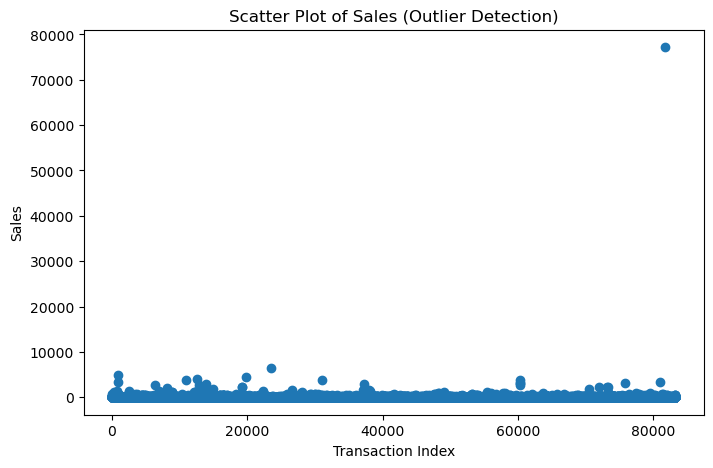

In [12]:
# Check for Outlier
# Use Scatter plot to detect outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_filtered.index,df_filtered['Sales'])

plt.title("Scatter Plot of Sales (Outlier Detection)")
plt.xlabel("Transaction Index")
plt.ylabel("Sales")
plt.show

## 5️⃣ Data Visualisation – Scatter Plot, Histogram, and Line Chart
<strong>Objective: Create scatter plots, histograms, and line charts to better understand the data.</strong>

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.


<function matplotlib.pyplot.show(close=None, block=None)>

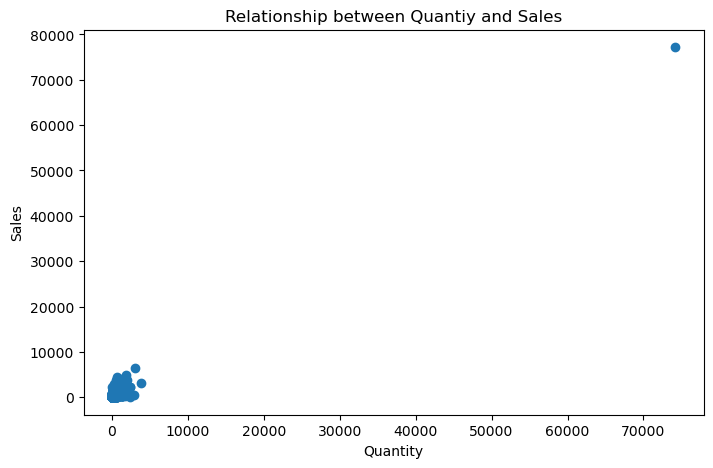

In [13]:
##Scatter plot: Relationship between Quantity and Sales

plt.figure(figsize=(8,5))
plt.scatter(df_filtered['Quantity'],df_filtered['Sales'])

plt.title("Relationship between Quantiy and Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show


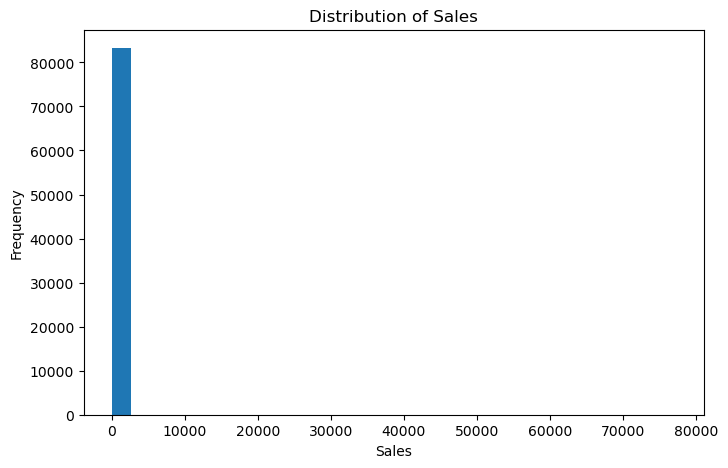

In [14]:
# Histogram: Distribution of Sales values
plt.figure(figsize=(8,5))
plt.hist(df_filtered['Sales'], bins= 30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

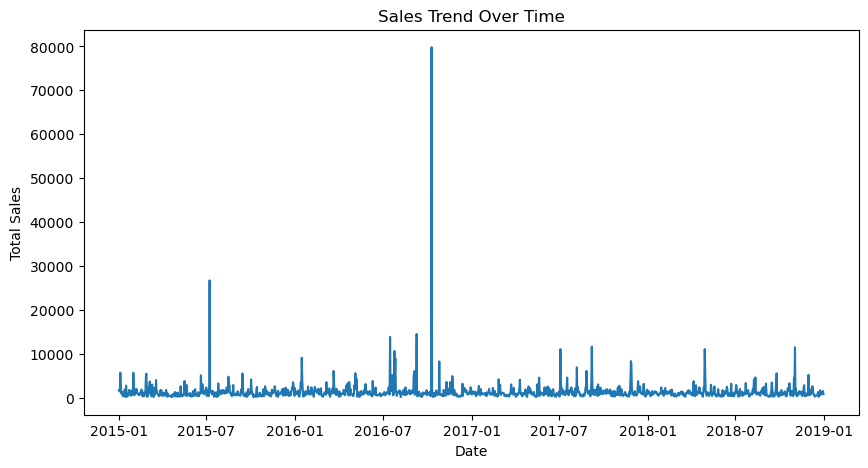

In [15]:
# Line chart: Sales trend over time
# Convert InvoiceDate to datetime format
df_filtered['InvoiceDate']= pd.to_datetime(df_filtered['InvoiceDate'])

# Aggregate total sales by date
sales_trend = df_filtered.groupby('InvoiceDate')['Sales'].sum()

# Create a line chart to show the trend of Sales over time
plt.figure(figsize=(10,5))
plt.plot(sales_trend.index, sales_trend.values)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

## 6️⃣ Correlation and Data Insights
<strong> Objective: Identify the relationship between different numerical columns in the dataset. </strong>

- Calculate the correlation between Quantity and Sales.
- Visualise the correlation matrix using a heatmap.

In [16]:
# Calculate Correlation Between Quantity and Sales
correlation = df_filtered['Quantity'].corr(df_filtered['Sales'])
print(f"Correlation between Quantity and Sales: {correlation}")

# Create a correlation matrix
corr_matrix = df_filtered[['Quantity', 'Sales']].corr()
display(corr_matrix)



Correlation between Quantity and Sales: 0.9786092498011625


In [ ]:
#install and import seaborn library
%pip install seaborn

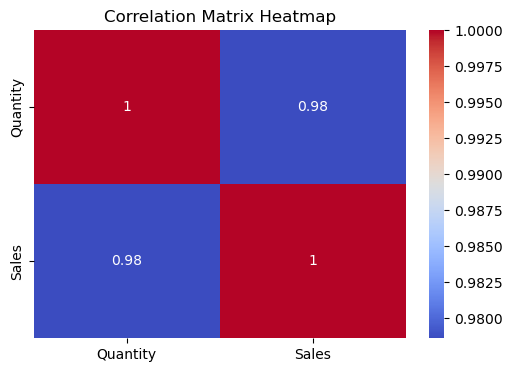

In [18]:
#Visualise the Correlation Matrix with a Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
#plot the heatmap
plt.figure(figsize=(6,4))

#Heatmap of correlations (annot=True shows values, cmap="coolwarm" sets the color scale

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix Heatmap")
plt.show()

## 7️⃣ Grouping and Aggregating
<strong> Objective: Perform grouping and aggregation operations to summarise the data. </strong>

- GroupBy operation: Group by Product_Category and calculate the total Sales per category.
- Create a Pivot Table to show Sales by Country and Product_Category.

In [19]:
# Group data by Product_Category and calculate total Sales
sales_by_category = df_merged.groupby('Product_Category')['Sales'].sum()

# Display the result
print("Total Sales per Product Category:")
display(sales_by_category)

Total Sales per Product Category:


In [20]:
# Create pivot table for Sales by Country and Product_Category
pivot_sales = pd.pivot_table(
    df_merged,
    values='Sales',
    index='Product_Category',
    columns='Country',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Display the pivot table
print("Sales by Country and Product Category:")
display(pivot_sales)

Sales by Country and Product Category:


📌 Conclusion

This project demonstrates a complete end-to-end analysis of sales data, from data extraction and exploration to forecasting. The analysis revealed key patterns in sales performance across products, regions, and time, providing a clearer understanding of business dynamics.

Exploratory Data Analysis (EDA) helped identify data distributions, relationships between variables.